# T07FakeMediaDetect - Hybrid Training (CNN + Benford's Law)

**Dự án:** Phát hiện ảnh số đã bị chỉnh sửa dựa trên Luật Benford kết hợp thuật toán học máy có giám sát.

**Chiến lược Training:**
1.  **Load Dataset:** Sử dụng CASIA v2.0 (và FIDAC nếu có).
2.  **Load Pre-trained CNN:** Tải mô hình CNN đã huấn luyện (để trích xuất đặc trưng ELA) thay vì training lại từ đầu (tiết kiệm thời gian).
3.  **Feature Extraction:**
    *   Trích xuất **CNN Features** (Output xác suất hoặc Dense layer).
    *   Trích xuất **Benford Features** (13 đặc trưng thống kê).
4.  **Hybrid Training:** Huấn luyện **SVM (Support Vector Machine)** trên tập đặc trưng kết hợp.

---

## 1. Setup & Dependencies
Cài đặt thư viện cần thiết.

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn opencv-python Pillow tensorflow kaggle

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image, ImageChops, ImageEnhance
from tqdm.notebook import tqdm
import random
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow import keras

# Set random seed
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


## 2. Dataset Preparation
### Cách 1: Tải trực tiếp từ Kaggle (Khuyên dùng)
1. Tạo API Token trên Kaggle (Account -> Create New API Token -> tải file `kaggle.json`).
2. Upload file `kaggle.json` vào Colab chạy cell dưới đây.

In [3]:
import os
from google.colab import files

# Kiểm tra folder datasets
if not os.path.exists('datasets'):
    os.makedirs('datasets')

# --- OPTION 1: KAGGLE DOWNLOAD ---
if not os.path.exists('kaggle.json'):
    print("Upload kaggle.json file to download dataset...")
    uploaded = files.upload()

if os.path.exists('kaggle.json'):
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    print("Downloading CASIA 2.0 dataset...")
    !kaggle datasets download -d divg07/casia-20-image-tampering-detection-dataset -p datasets --unzip
    print("Download completed.")
else:
    print("Skipping Kaggle download (kaggle.json not found). Assuming manual upload.")

Upload kaggle.json file to download dataset...


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/divg07/casia-20-image-tampering-detection-dataset
License(s): unknown
 99% 2.53G/2.56G [00:09<00:00, 645MB/s]
100% 2.56G/2.56G [00:09<00:00, 288MB/s]
Download completed.


In [4]:
def load_image_paths(base_path, sample_size=None):
    authentic_paths = []
    forged_paths = []

    print(f"Scanning directory: {base_path}")
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.tif')):
                path = os.path.join(root, file)
                # Heuristic identify Au/Tp based on folder name
                if 'au' in root.lower() or 'original' in root.lower():
                    authentic_paths.append(path)
                elif 'tp' in root.lower() or 'forged' in root.lower() or 'tampered' in root.lower():
                    forged_paths.append(path)

    print(f"Found {len(authentic_paths)} Authentic images")
    print(f"Found {len(forged_paths)} Forged images")

    if sample_size:
        if len(authentic_paths) > sample_size:
            authentic_paths = random.sample(authentic_paths, sample_size)
        if len(forged_paths) > sample_size:
            forged_paths = random.sample(forged_paths, sample_size)

    paths = authentic_paths + forged_paths
    labels = [0] * len(authentic_paths) + [1] * len(forged_paths)

    df = pd.DataFrame({'path': paths, 'label': labels})
    df = df.sample(frac=1).reset_index(drop=True)
    return df

# LOAD DATASET
DATASET_PATH = 'datasets' # Root folder where data was unzipped
df = load_image_paths(DATASET_PATH, sample_size=3000) # Adjust sample_size as needed
print(df.head())

Scanning directory: datasets
Found 7437 Authentic images
Found 5123 Forged images
                                                path  label
0                datasets/CASIA2/Au/Au_cha_30113.jpg      0
1  datasets/CASIA2/Tp/Tp_S_CRN_S_N_pla00060_pla00...      1
2                datasets/CASIA2/Au/Au_arc_30719.jpg      0
3                datasets/CASIA2/Au/Au_pla_30399.jpg      0
4  datasets/CASIA2/Tp/Tp_D_CRN_S_N_cha10188_cha00...      1


## 3. Preprocessing & Feature Extraction
Định nghĩa các hàm ELA và Benford.

In [5]:
# --- ELA FUNCTION ---
def convert_to_ela_image(path, quality=90):
    temp_filename = 'temp_ela.jpg'
    try:
        image = Image.open(path).convert('RGB')
        image.save(temp_filename, 'JPEG', quality=quality)
        resaved_image = Image.open(temp_filename)

        ela_image = ImageChops.difference(image, resaved_image)

        extrema = ela_image.getextrema()
        max_diff = max([ex[1] for ex in extrema])
        if max_diff == 0: max_diff = 1
        scale = 255.0 / max_diff

        return ImageEnhance.Brightness(ela_image).enhance(scale)
    except:
        return None

def prepare_image_cnn(image_path, image_size=(128, 128)):
    ela_image = convert_to_ela_image(image_path)
    if ela_image is None:
        return np.zeros((image_size[0], image_size[1], 3))
    return np.array(ela_image.resize(image_size)) / 255.0

# --- BENFORD FUNCTION ---
def extract_benford_features(image_path):
    try:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None: return np.zeros(13)

        # Resize for speed if too large
        if img.shape[0] > 1000: img = cv2.resize(img, (0,0), fx=0.5, fy=0.5)

        # DCT block processing
        img = np.float32(img)
        h, w = img.shape
        first_digits = []

        # Loop 8x8 blocks
        for i in range(0, h-8, 8):
            for j in range(0, w-8, 8):
                block = cv2.dct(img[i:i+8, j:j+8])
                coeffs = block.flatten()[1:] # Skip DC
                for val in coeffs:
                    if abs(val) >= 1:
                        first_digits.append(int(str(int(abs(val)))[0]))

        if not first_digits: return np.zeros(13)

        # Calc distribution
        total = len(first_digits)
        observed = np.array([first_digits.count(d)/total for d in range(1,10)])
        expected = np.array([np.log10(1+1/d) for d in range(1,10)])

        # Metrics
        chi_sq = np.sum((observed-expected)**2/expected)*total
        ks = np.max(np.abs(np.cumsum(observed)-np.cumsum(expected)))
        mad = np.mean(np.abs(observed-expected))
        mse = np.mean((observed-expected)**2)

        return np.concatenate([observed, [chi_sq/1000.0, ks, mad, mse]])
    except:
        return np.zeros(13)

## 4. Load Pre-trained CNN Model
Upload file model `.h5` của bạn lên Colab (kéo thả vào Files view).
Nếu chưa có module pre-trained, code sẽ báo lỗi và yêu cầu tải lên.

In [6]:
MODEL_PATH = 'proposed_ela_50_casia_fidac.h5'

if not os.path.exists(MODEL_PATH):
    print(f"Model file {MODEL_PATH} not found!")
    print("Please upload your pre-trained .h5 model file.")
    uploaded_model = files.upload()

try:
    cnn_model = load_model(MODEL_PATH)
    print("Pre-trained CNN Model Loaded Successfully!")
    cnn_model.summary()
except Exception as e:
    print(f"Failed to load model: {e}")
    print("You must upload a valid .h5 model file to proceed without re-training.")

Model file proposed_ela_50_casia_fidac.h5 not found!
Please upload your pre-trained .h5 model file.


Saving proposed_ela_50_casia_fidac.h5 to proposed_ela_50_casia_fidac.h5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Pre-trained CNN Model Loaded Successfully!


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_71 (Conv2D)              │ (None, 124, 124, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 26, 26, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 11, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │     1,982,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,118,595 (11.90 MB)

 Trainable params: 3,118,593 (11.90 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## 5. Extract Hybrid Features
Chạy dữ liệu qua CNN để lấy xác suất, và chạy qua hàm Benford để lấy thống kê.

In [7]:
X_cnn_probs = []
X_benford = []
Y = []

print("Starting Feature Extraction...")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    path = row['path']

    # 1. Get CNN Probability
    ela_input = prepare_image_cnn(path)
    ela_input = np.expand_dims(ela_input, axis=0) # Add batch dim (1, 128, 128, 3)
    prob = cnn_model.predict(ela_input, verbose=0)[0][0]

    # 2. Get Benford Features
    benford = extract_benford_features(path)

    X_cnn_probs.append(prob)
    X_benford.append(benford)
    Y.append(row['label'])

# Convert to arrays
X_cnn_probs = np.array(X_cnn_probs).reshape(-1, 1) # Shape (N, 1)
X_benford = np.array(X_benford) # Shape (N, 13)
Y = np.array(Y)

# Combine Features: [CNN_Prob, Benford_Stat]
X_hybrid = np.hstack((X_cnn_probs, X_benford))

print(f"Hybrid Feature Shape: {X_hybrid.shape}")

Starting Feature Extraction...


  0%|          | 0/6000 [00:00<?, ?it/s]

Hybrid Feature Shape: (6000, 14)


## 6. Train SVM (Meta-Classifier)
Training mô hình SVM trên tập features kết hợp.

In [8]:
# Split Data
X_train, X_test, Y_train, Y_test = train_test_split(X_hybrid, Y, test_size=0.2, random_state=42, stratify=Y)

# Normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM
print("Training SVM...")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, Y_train)
print("Training Complete!")

# Evaluate
preds = svm_model.predict(X_test_scaled)
print("\nClassification Report:")
print(classification_report(Y_test, preds))
print(f"Accuracy: {accuracy_score(Y_test, preds):.4f}")

Training SVM...
Training Complete!

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       600
           1       0.79      0.82      0.81       600

    accuracy                           0.80      1200
   macro avg       0.80      0.80      0.80      1200
weighted avg       0.80      0.80      0.80      1200

Accuracy: 0.8008


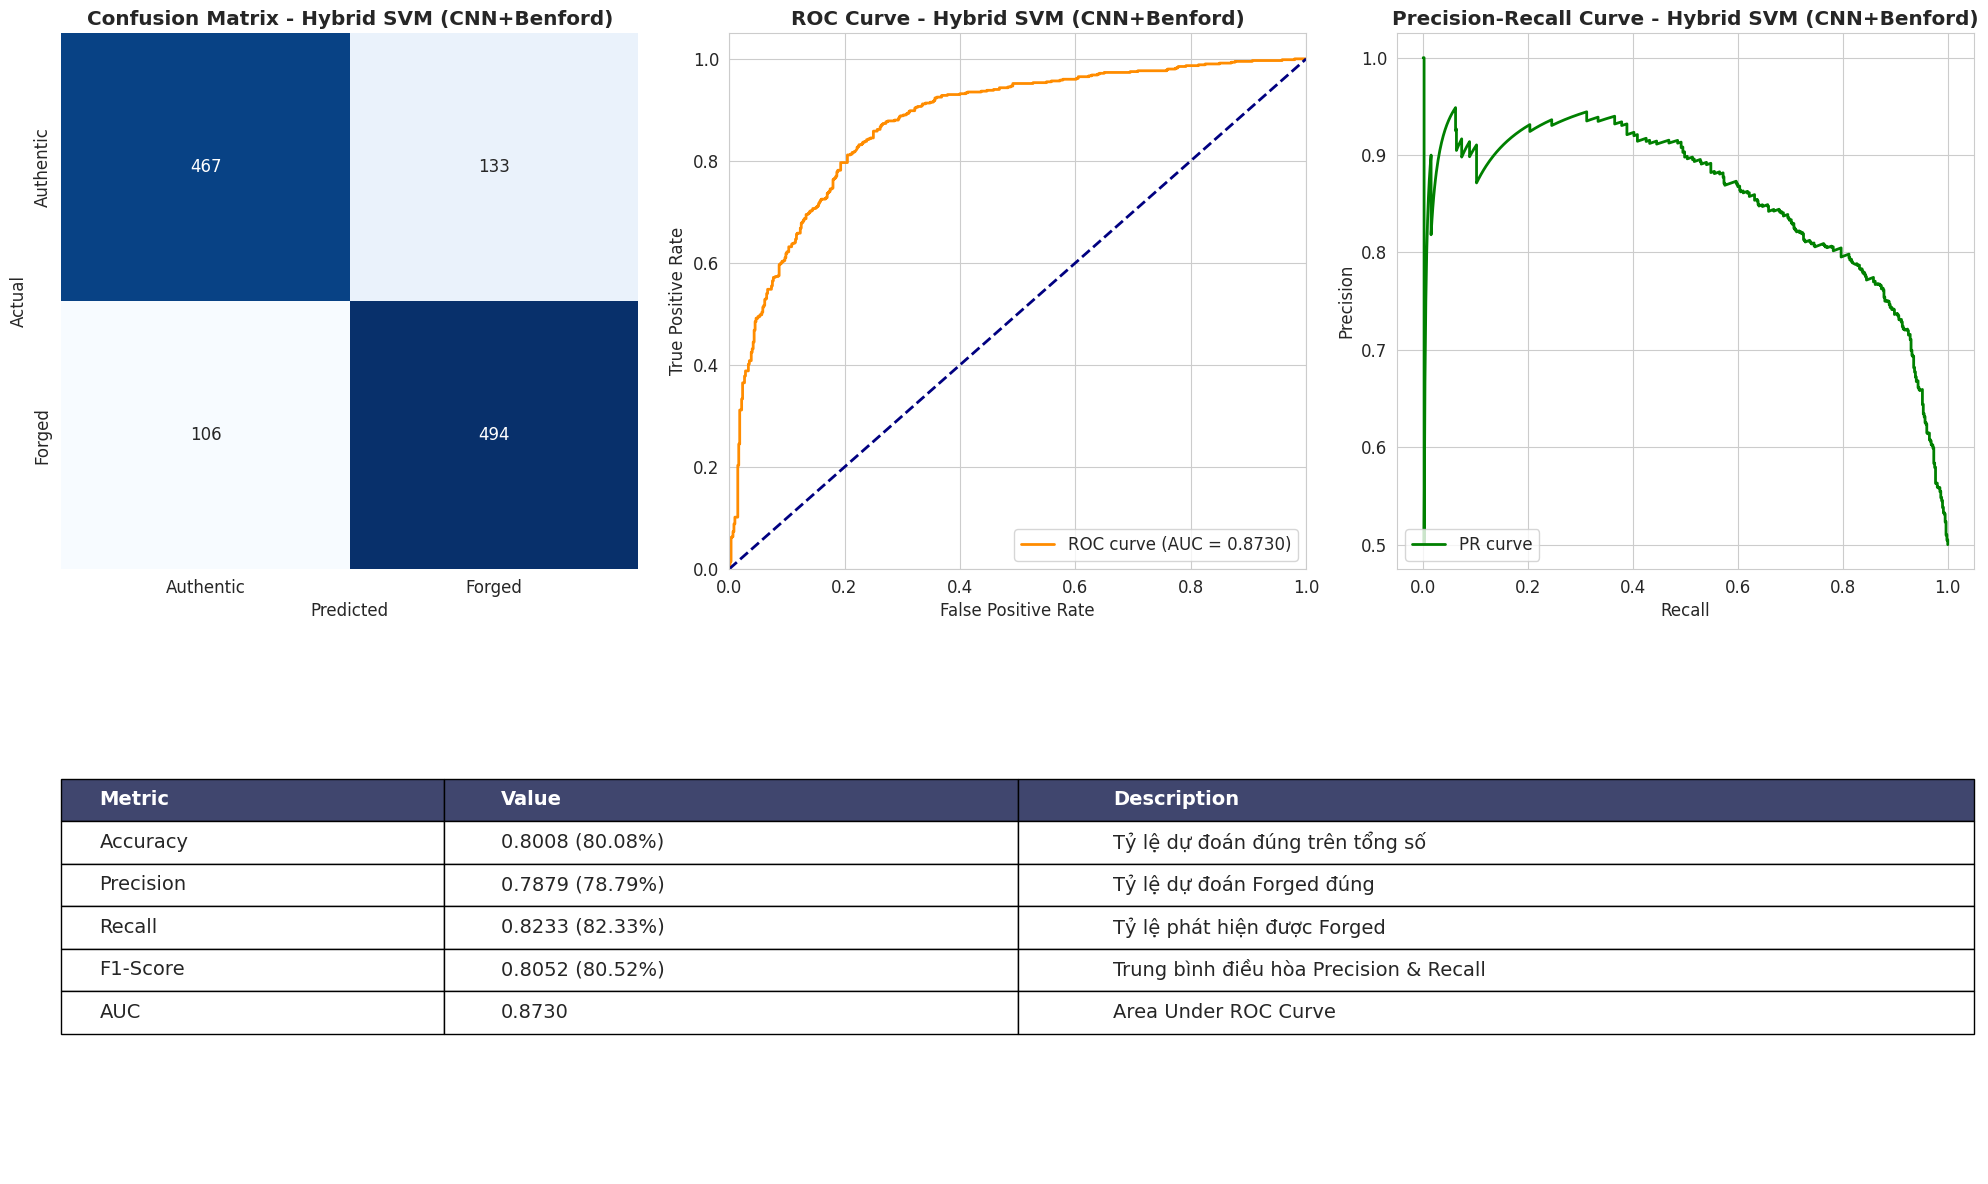


DETAILED CLASSIFICATION REPORT - Hybrid SVM (CNN+Benford)
              precision    recall  f1-score   support

   Authentic     0.8150    0.7783    0.7962       600
      Forged     0.7879    0.8233    0.8052       600

    accuracy                         0.8008      1200
   macro avg     0.8014    0.8008    0.8007      1200
weighted avg     0.8014    0.8008    0.8007      1200



In [13]:
# 1. Tính xác suất (Probability) dùng cho biểu đồ ROC
probs = svm_model.predict_proba(X_test_scaled)[:, 1]

# 2. Vẽ biểu đồ đánh giá
plot_scientific_metrics(Y_test, preds, probs, model_name="Hybrid SVM (CNN+Benford)")

In [10]:
# Save Hybrid Components
import joblib
joblib.dump(svm_model, 'hybrid_svm_benford.pkl')
joblib.dump(scaler, 'hybrid_scaler.pkl')
print("Saved SVM model and Scaler.")

Saved SVM model and Scaler.


CELL cuối để visualization kết quả

Đang vẽ biểu đồ đánh giá...


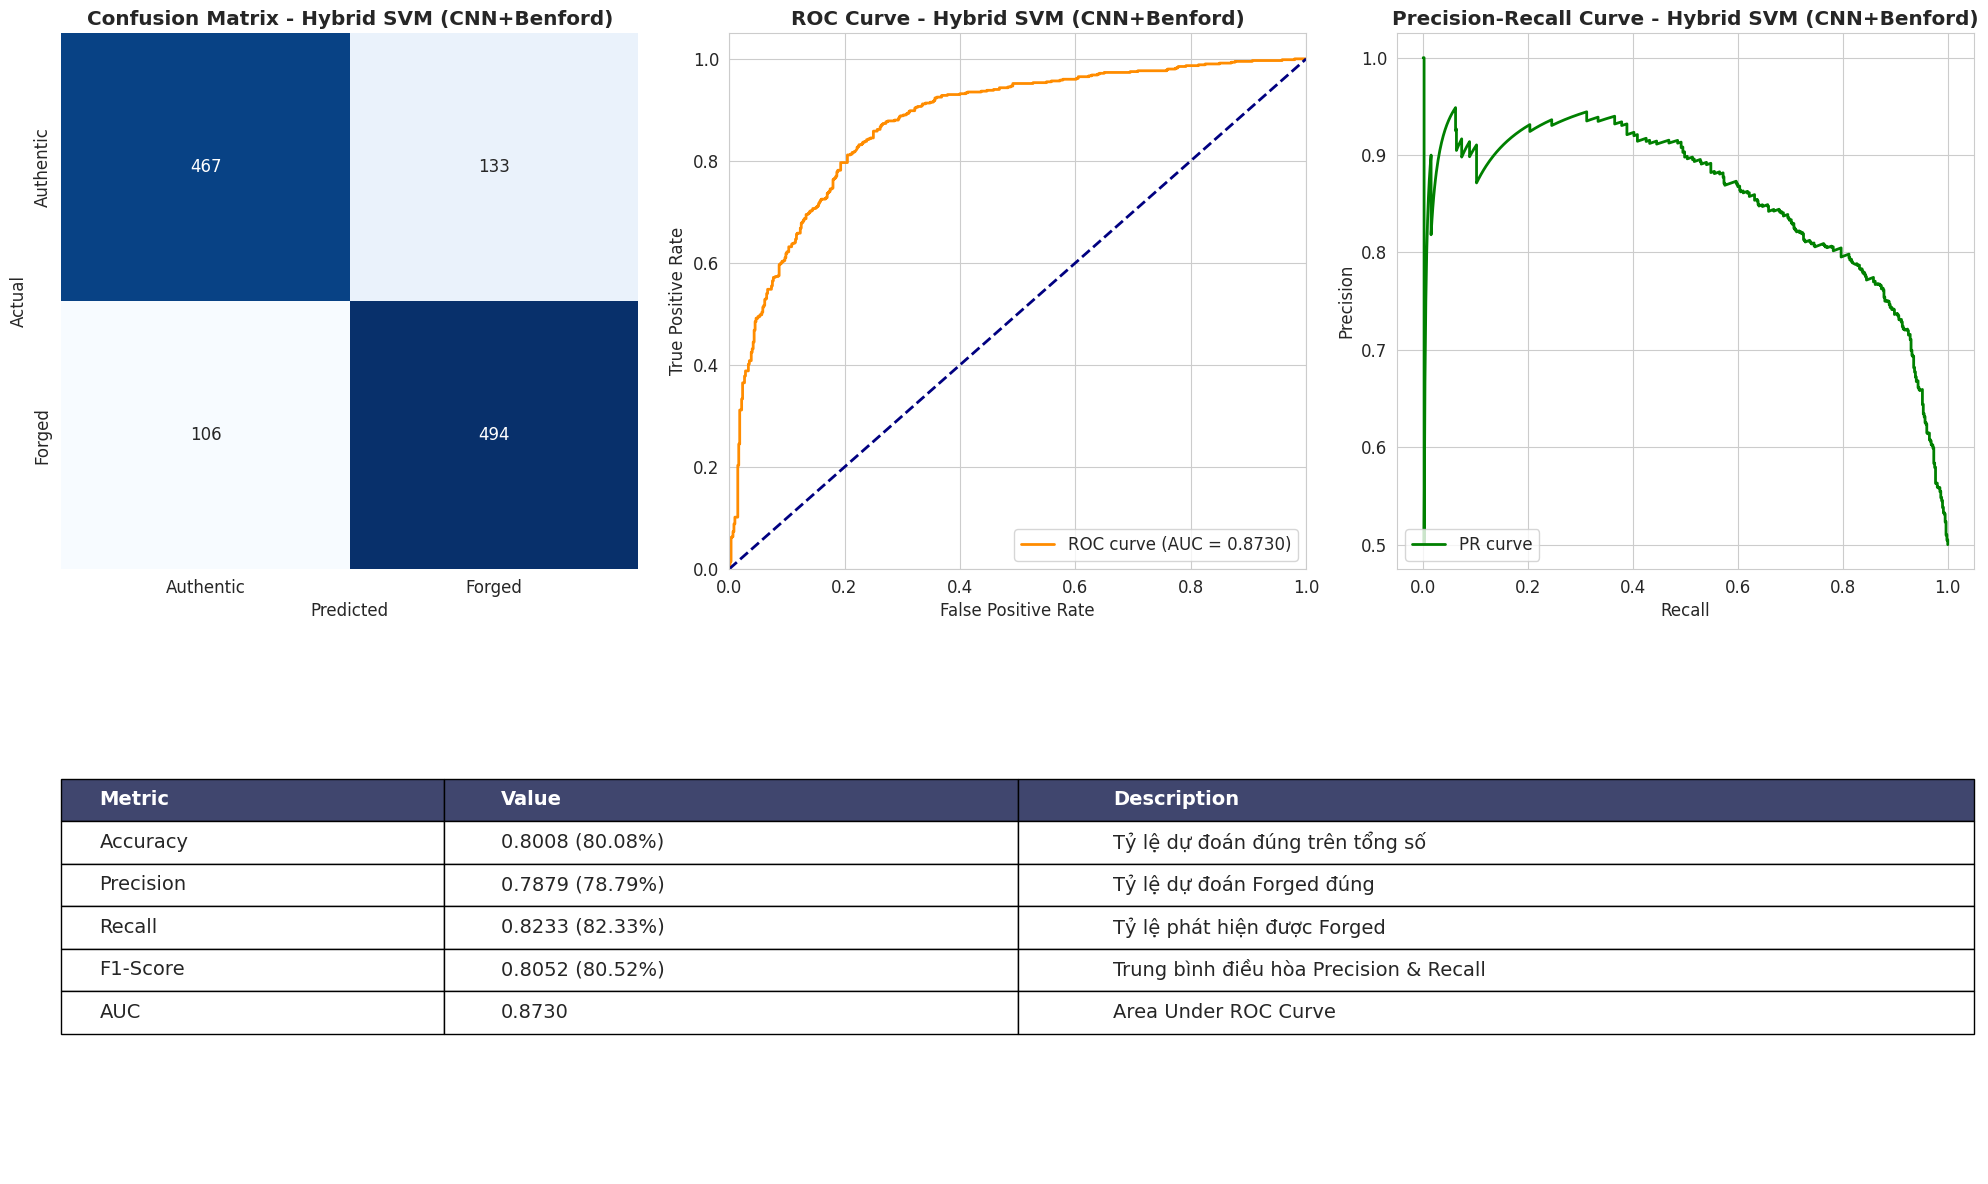


DETAILED CLASSIFICATION REPORT - Hybrid SVM (CNN+Benford)
              precision    recall  f1-score   support

   Authentic     0.8150    0.7783    0.7962       600
      Forged     0.7879    0.8233    0.8052       600

    accuracy                         0.8008      1200
   macro avg     0.8014    0.8008    0.8007      1200
weighted avg     0.8014    0.8008    0.8007      1200



In [14]:
# --- ADVANCED VISUALIZATION & EVALUATION ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve

def plot_scientific_metrics(y_true, y_pred, y_prob, model_name="Hybrid Model"):
    """
    Vẽ các biểu đồ đánh giá chuẩn khoa học và bảng số liệu chi tiết.
    """
    # Set style
    sns.set_style("whitegrid")
    plt.rcParams.update({'font.size': 12})

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(2, 3)

    # 1. Confusion Matrix
    ax1 = fig.add_subplot(gs[0, 0])
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False,
                xticklabels=['Authentic', 'Forged'], yticklabels=['Authentic', 'Forged'])
    ax1.set_title(f'Confusion Matrix - {model_name}', fontweight='bold')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')

    # 2. ROC Curve
    ax2 = fig.add_subplot(gs[0, 1])
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title(f'ROC Curve - {model_name}', fontweight='bold')
    ax2.legend(loc="lower right")

    # 3. Precision-Recall Curve
    ax3 = fig.add_subplot(gs[0, 2])
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ax3.plot(recall, precision, color='green', lw=2, label='PR curve')
    ax3.set_xlabel('Recall')
    ax3.set_ylabel('Precision')
    ax3.set_title(f'Precision-Recall Curve - {model_name}', fontweight='bold')
    ax3.legend(loc="lower left")

    # 4. Metrics Table (Render as text/table plot)
    ax4 = fig.add_subplot(gs[1, :])
    ax4.axis('off')

    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Create Table Data
    table_data = [
        ['Metric', 'Value', 'Description'],
        ['Accuracy', f"{acc:.4f} ({acc*100:.2f}%)", 'Tỷ lệ dự đoán đúng trên tổng số'],
        ['Precision', f"{prec:.4f} ({prec*100:.2f}%)", 'Tỷ lệ dự đoán Forged đúng'],
        ['Recall', f"{rec:.4f} ({rec*100:.2f}%)", 'Tỷ lệ phát hiện được Forged'],
        ['F1-Score', f"{f1:.4f} ({f1*100:.2f}%)", 'Trung bình điều hòa Precision & Recall'],
        ['AUC', f"{roc_auc:.4f}", 'Area Under ROC Curve']
    ]

    table = ax4.table(cellText=table_data, loc='center', cellLoc='left', colWidths=[0.2, 0.3, 0.5])
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.scale(1, 2) # Tăng chiều cao dòng

    # Style the header
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#40466e')

    plt.tight_layout()
    plt.show()

    # Print Classification Report text as well
    print("\n" + "="*60)
    print(f"DETAILED CLASSIFICATION REPORT - {model_name}")
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=['Authentic', 'Forged'], digits=4))

# --- GỌI HÀM VẼ BIỂU ĐỒ ---
print("Đang vẽ biểu đồ đánh giá...")
# y_test, preds, hybrid_probs lấy từ bước trước
# plot_scientific_metrics(Y_test, preds, hybrid_probs, model_name="Hybrid SVM (CNN+Benford)")
plot_scientific_metrics(Y_test, preds, probs, model_name="Hybrid SVM (CNN+Benford)")

In [15]:
# 1. Trích xuất dự đoán của riêng CNN từ tập Test (Cột đầu tiên của X_test)
cnn_probs_test = X_test[:, 0]  # X_test chưa scale chứa giá trị gốc
cnn_preds_test = (cnn_probs_test > 0.5).astype(int)

# 2. Tính độ chính xác của CNN
acc_cnn = accuracy_score(Y_test, cnn_preds_test)

print(f"✅ Accuracy CNN Only:   {acc_cnn:.4f} ({acc_cnn*100:.2f}%)")
print(f"✅ Accuracy Hybrid SVM: {accuracy_score(Y_test, preds):.4f} ({accuracy_score(Y_test, preds)*100:.2f}%)")

# 3. So sánh
diff = accuracy_score(Y_test, preds) - acc_cnn
if diff > 0:
    print(f"\n=> Kết luận: Hybrid Model CẢI THIỆN độ chính xác thêm {diff*100:.2f}% so với CNN gốc.")
else:
    print(f"\n=> Kết luận: Hybrid Model thấp hơn {abs(diff)*100:.2f}% (Có thể do nhiễu từ Benford hoặc tập mẫu nhỏ).")

✅ Accuracy CNN Only:   0.4942 (49.42%)
✅ Accuracy Hybrid SVM: 0.8008 (80.08%)

=> Kết luận: Hybrid Model CẢI THIỆN độ chính xác thêm 30.67% so với CNN gốc.


In [16]:
import joblib
from google.colab import files

print("Đang chuẩn bị download...")

# 1. Xác định biến model (svm_model hoặc svm)
model_to_save = None
if 'svm_model' in locals():
    model_to_save = svm_model
elif 'svm' in locals():
    model_to_save = svm

if model_to_save:
    # 2. Lưu SVM Model ra file .pkl
    svm_filename = 'hybrid_svm_model.pkl'
    joblib.dump(model_to_save, svm_filename)
    print(f"--> Đã lưu model: {svm_filename}")
    files.download(svm_filename)

    # 3. Lưu Scaler (QUAN TRỌNG)
    if 'scaler' in locals():
        scaler_filename = 'hybrid_scaler.pkl'
        joblib.dump(scaler, scaler_filename)
        print(f"--> Đã lưu scaler: {scaler_filename}")
        files.download(scaler_filename)
    else:
        print("⚠️ CẢNH BÁO: Không tìm thấy biến 'scaler'.")
else:
    print("❌ LỖI: Không tìm thấy model đã train (biến 'svm_model' hoặc 'svm').")

Đang chuẩn bị download...
--> Đã lưu model: hybrid_svm_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

--> Đã lưu scaler: hybrid_scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
from google.colab import files
import os

# Tên file chính xác mà WebApp yêu cầu
filename = 'proposed_ela_50_casia_fidac.h5'

# Kiểm tra xem file đã tồn tại chưa
if os.path.exists(filename):
    print(f"✅ Đang download model tương thích WebApp: {filename}")
    files.download(filename)
else:
    # Nếu chưa có file trên đĩa, thử lưu từ biến 'model' (model CNN bạn đã train)
    if 'model' in locals():
        print(f"💾 Đang lưu model CNN ra file {filename}...")
        model.save(filename)
        files.download(filename)
        print("✅ Đã bắt đầu download!")
    else:
        print("❌ LỖI: Không tìm thấy model CNN (biến 'model'). Hãy chắc chắn bạn đã chạy bước 'Build & Train CNN Model'.")

✅ Đang download model tương thích WebApp: proposed_ela_50_casia_fidac.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>